# Secondary Plots

Contains plots that build on data cached for plots from `provenance_explorer.analysis.*`.

In [5]:
from provenance_explorer.registry.registry_all import WORK, get_big_registry
from provenance_explorer.plotting import apply_style, palette

import json
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

from collections import defaultdict
from datetime import datetime, timezone, timedelta
from pathlib import Path

from itertools import combinations

from provenance_explorer.plotting import apply_style
from provenance_explorer.registry.registry_all import CACHE_ROOT

apply_style()

cache_path = WORK / "provenance-explorer-cache"

## CDM Type distribution bar chart

Requires `.correctness.data_model_types_plot` to be cached. 

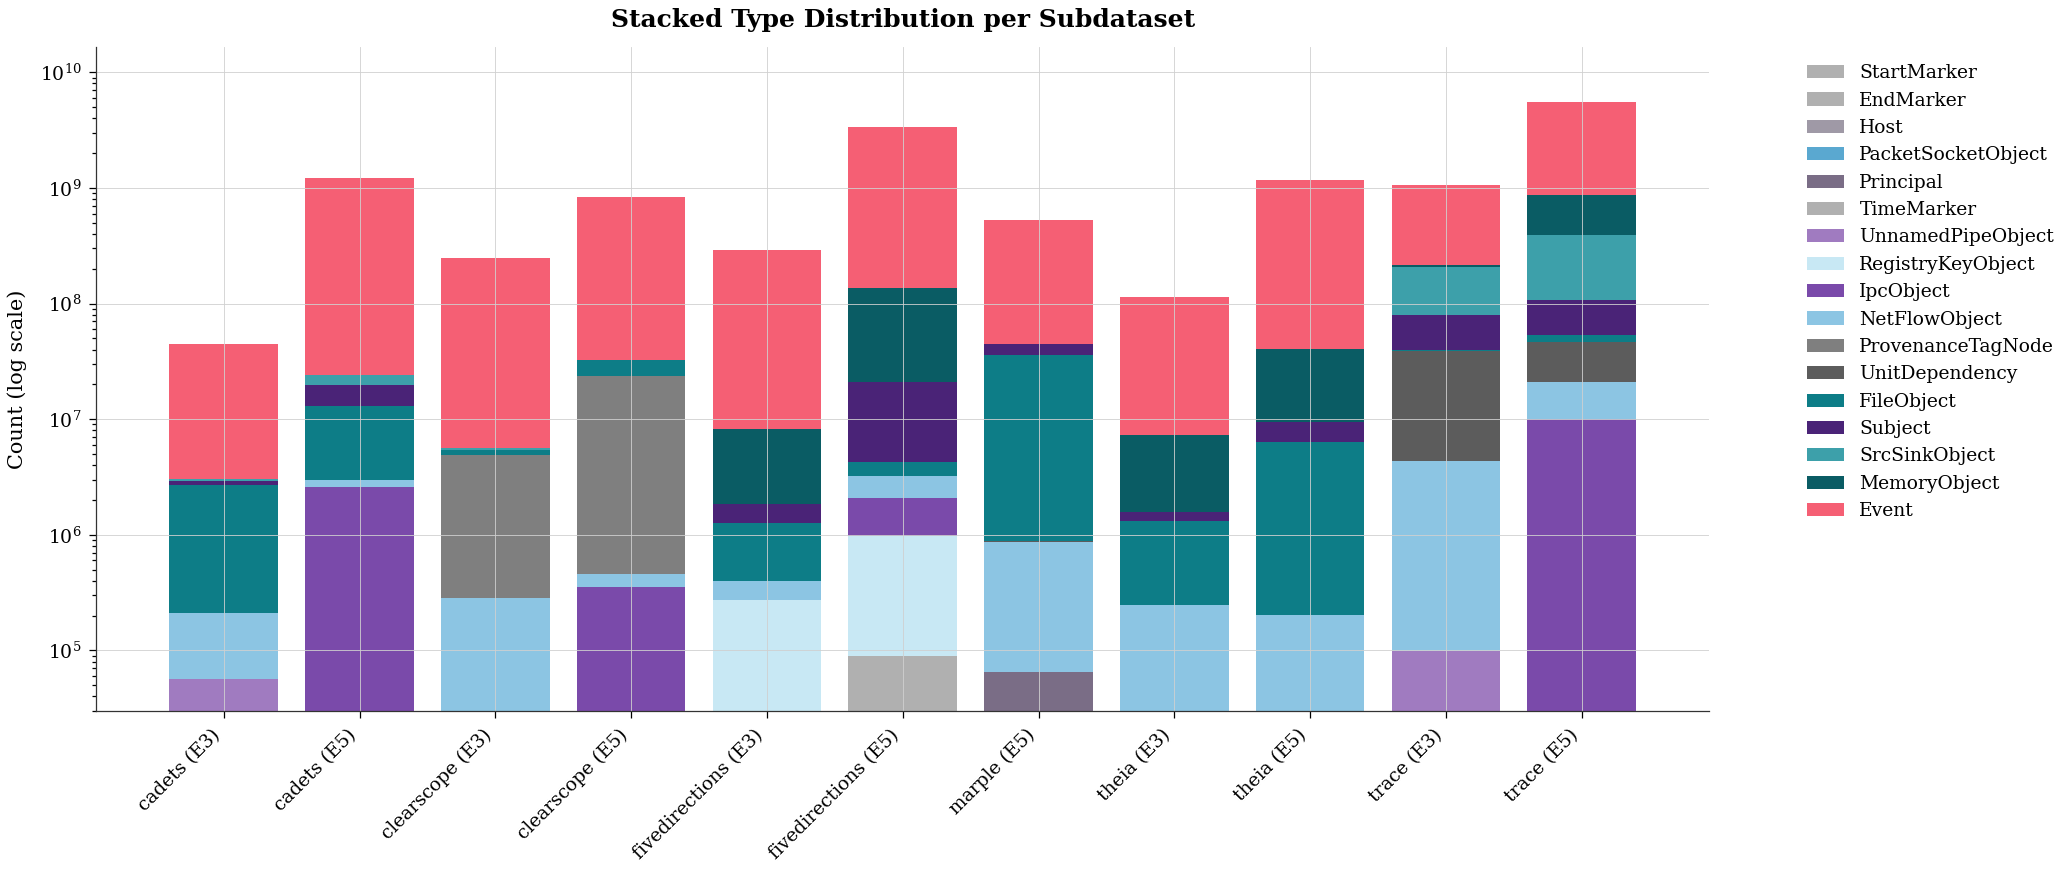

In [6]:
data_models = ["cdm20.json", "cdm18.json"]

type_colors = {
    # process-ish
    "Subject":              "#4a2377",
    "IpcObject":            "#7a4aaa",
    "UnnamedPipeObject":    "#a07bc0",

    # file-ish
    "FileObject":           "#0d7d87",
    "SrcSinkObject":        "#3da0aa",
    "MemoryObject":         "#0a5c64",

    # network-ish
    "NetFlowObject":        "#8cc5e3",
    "PacketSocketObject":   "#5aa8d0",

    # event
    "Event":                "#f55f74",

    # rare/meta
    "Principal":            "#7a6d86",
    "Host":                 "#9f99a6",

    # windows-only
    "RegistryKeyObject":    "#c8e8f4",

    # cdm metadata
    "TimeMarker":           "#b0b0b0",
    "StartMarker":          "#b0b0b0",
    "EndMarker":            "#b0b0b0",
    "ProvenanceTagNode":    "#7f7f7f",
    "UnitDependency":       "#5c5c5c",
}

bars = []
global_type_totals = defaultdict(int)

for data_model in data_models:
    summary_path = cache_path / "data_model_types_plot" / data_model
    with open(summary_path, "r") as fh:
        summary = json.load(fh)

    for subdataset, subdict in summary.items():
        type_counts = defaultdict(int)

        for key, val in subdict.items():
            c = sum(val.values())
            type_counts[key] += c
            global_type_totals[key] += c

        label = f"{subdataset} ({"E3" if data_model == "cdm18.json" else "E5"})"
        bars.append((label, dict(type_counts)))

bars = sorted(bars, key= lambda t: t[0])
types_sorted = sorted(global_type_totals, key=lambda t: global_type_totals[t])

fig, ax = plt.subplots(figsize=(14, 6))
x = list(range(len(bars)))
bottom = [0] * len(bars)

for t in types_sorted:
    values = [counts.get(t, 0) for _, counts in bars]
    ax.bar(x, values, bottom=bottom, label=t,color=type_colors.get(t, "#CCCCCC"),)
    bottom = [b + v for b, v in zip(bottom, values)]

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([label for label, _ in bars], rotation=45, ha="right")

ax.set_ylabel("Count (log scale)")
ax.set_title("Stacked Type Distribution per Subdataset")

ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

# OpTC fleet-wide event-rate overlay

In [7]:
OPTC_SUB_DATASETS = ["aia_51_75", "aia_201_225", "aia_501_525", "aia_951_975"]
BIN_SEC = 5 * 60

# so 2019-09-20 20:00 UTC = 2019-09-21 00:00 local.
LOCAL_TZ = timezone(timedelta(hours=+4))
WINDOW_START_NS = int(datetime(2019, 9, 20, 20, 0, 0, tzinfo=timezone.utc).timestamp()) * 1_000_000_000
WINDOW_END_NS   = int(datetime(2019, 9, 21, 20, 0, 0, tzinfo=timezone.utc).timestamp()) * 1_000_000_000

def _load_subdataset(sub_dataset: str) -> pd.DataFrame:
    path = CACHE_ROOT / "events_per_host_plot" / "optc" / sub_dataset / "events_per_host.parquet"
    df = pd.read_parquet(path)
    df["sub_dataset"] = sub_dataset
    return df


frames = [_load_subdataset(sd) for sd in OPTC_SUB_DATASETS]
raw = pd.concat(frames, ignore_index=True)

raw = raw[(raw["time_bin_ns"] >= WINDOW_START_NS) & (raw["time_bin_ns"] < WINDOW_END_NS)]

totals = raw.groupby(["host_id", "time_bin_ns"], as_index=False)["count"].sum()
rate_wide = (
    totals
    .pivot(index="time_bin_ns", columns="host_id", values="count")
    .sort_index()
    / BIN_SEC
)
# as we can nozt distinguish a true 0 event host from a missing file
rate_wide = rate_wide.where(rate_wide > 0)

print(f"hosts: {rate_wide.shape[1]}, time bins: {rate_wide.shape[0]}, observed cells: {int(rate_wide.notna().sum().sum())}")
rate_wide.iloc[:3, :4]

active = rate_wide.loc[:, rate_wide.std(axis=0) > 0]
corr = active.corr(method="pearson")
iu = np.triu_indices_from(corr.values, k=1)
pairwise = corr.values[iu]
mean_corr = float(np.nanmean(pairwise))
median_corr = float(np.nanmedian(pairwise))
# print(f"mean pairwise Pearson r = {mean_corr:.3f} (median {median_corr:.3f}, n_pairs={len(pairwise)})")

hosts: 100, time bins: 288, observed cells: 26520


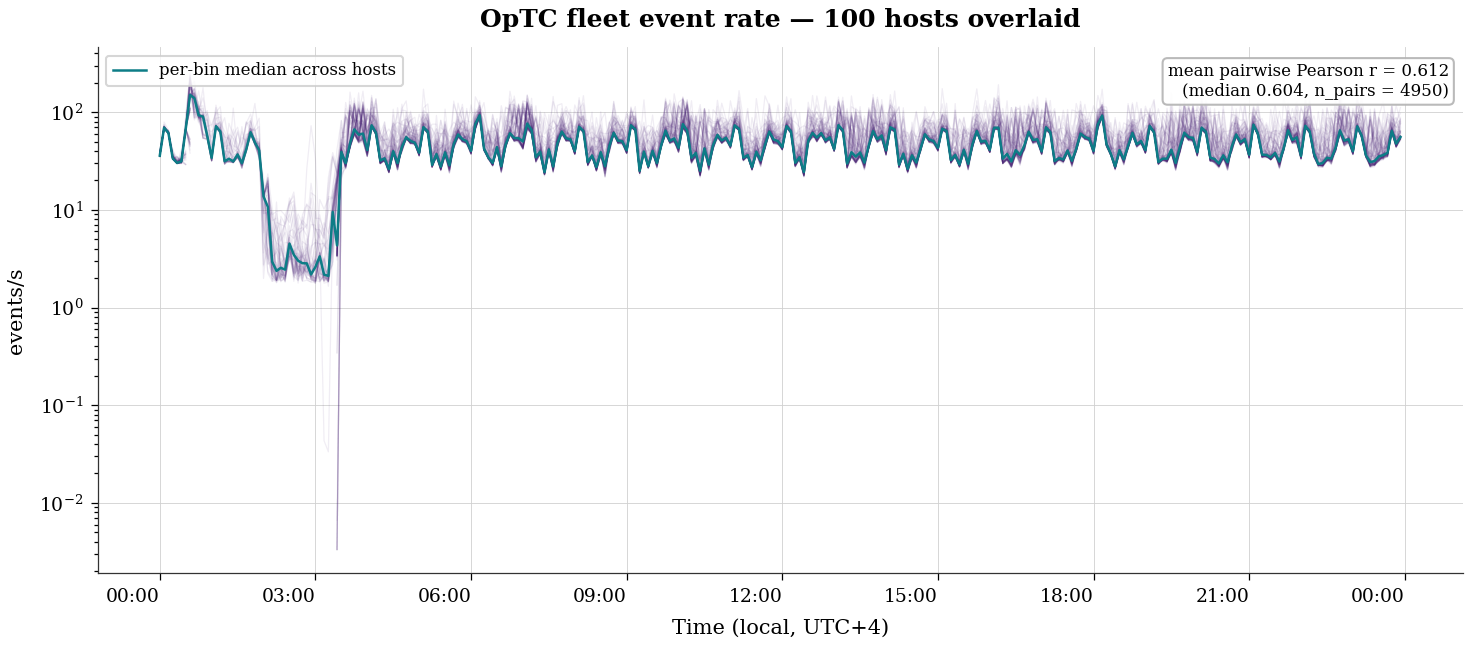

In [8]:
LOG_SCALE = True 

times = [datetime.fromtimestamp(t / 1e9, tz=LOCAL_TZ) for t in rate_wide.index]
plot_values = rate_wide.values 

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(times, plot_values, color="C0", alpha=0.08, linewidth=0.6)

median_trace = np.nanmedian(plot_values, axis=1)
ax.plot(times, median_trace, color="C3", linewidth=1.2, label="per-bin median across hosts")

if LOG_SCALE:
    ax.set_yscale("log")

ax.set_ylabel("events/s")
ax.set_xlabel("Time (local, UTC+4)")
ax.set_title(f"OpTC fleet event rate — {rate_wide.shape[1]} hosts overlaid")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=LOCAL_TZ))
ax.xaxis.set_major_locator(mdates.HourLocator(byhour=range(0, 24, 3), tz=LOCAL_TZ))

ax.text(
    0.99, 0.97,
    f"mean pairwise Pearson r = {mean_corr:.3f}\n(median {median_corr:.3f}, n_pairs = {len(pairwise)})",
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=8,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="0.7", alpha=0.9),
)
ax.legend(loc="upper left", fontsize=8, frameon=True)

fig.autofmt_xdate(rotation=0)
fig.tight_layout()
plt.show()